# 02a · Per-mode recovery on the soft probe: EB, EB+GP, GP and low-rank (Phase 2a, feeds Fig. 3)

**Question.** Does physics win at small N on every mode, and does the N window where it wins
widen with the number of nodes in the span?

**Data.** PPP-CONTAu 1 µm dense map: 346 positions, 100–445 µm, 100 nN, 0 V, PFM drive,
zero NaN (`ppp_dense_1um`). This replaces the 5 µm, 75-position sweep used on 2026-09-19
(`softprobe-recovery-vs-N-status`). That sweep resolved CR5's nodes (90 µm apart) only
marginally.

**Arms.** Every arm sees only the selected positions and is scored on the held-out ones.
- **EB**: `activemodemap.inference.PhysicsPosterior` with ζ fitted, a complex gain solved
  per evaluation, the tip setback fitted and f0 fixed at the measured 13.649 kHz, via
  `fmmpaper.physrec`. This is the 2026-09-17 package (branch
  `feat/position-scale-and-reanalysis`).
- **EB+GP**: the EB fit plus the package's discrepancy GP (`HybridSurrogate`).
- **GP**: model-free, PRESS length scale (`recon.rec_gp`, the draft's Grid B arm).
- **Low-rank**: Chebyshev basis, rank ≤ 6 (`recon.rec_lowrank`). The live protocol uses the
  same rank.

Designs are equispaced over the span, including both ends (the Grid B protocol).

**Runtime.** About 70–80 s per EB fit, so ~1 h for 5 modes × 9 budgets. Results are
cached per (mode, N) in `results/_cache_02a.json`, and a rerun resumes where it stopped.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json, time
from fmmpaper import physrec
s = F.load("ppp_dense_1um")
x = s.x_um - s.probe.clamp_offset_um        # stage frame; no static-shape anchor for this probe yet
BANDS = ["CR1", "CR2", "CR3", "CR4", "CR5"]
NS = [3, 4, 5, 6, 8, 10, 14, 20, 30]
GEOM = physrec.GEOM["pppcontau"]
band_data = {b: physrec.band_slice(s.freq_Hz, s.Z[0], s.probe.bands_Hz[b], n_max=250) for b in BANDS}
print(s)
print({b: (z.shape, round(f[0] / 1e3, 1), round(f[-1] / 1e3, 1)) for b, (z, f) in band_data.items()})

Series('ppp_dense_1um', probe=pppcontau, Z(1, 346, 47040), x 100.0-445.0 um, f 0.1-1100.1 kHz, bias_V=[0.0], load_nN=[100.0], spot=[])
{'CR1': ((346, 211), np.float64(50.3), np.float64(79.7)), 'CR2': ((346, 244), np.float64(180.1), np.float64(219.9)), 'CR3': ((346, 233), np.float64(380.1), np.float64(439.8)), 'CR4': ((346, 240), np.float64(650.2), np.float64(739.6)), 'CR5': ((346, 237), np.float64(975.2), np.float64(1074.6))}


## Ground truth: resonance, Q and nodes of each mode on the dense map

In [3]:
def nodes_of(Zb, fb):
    pk = spectra.peaks_along_x(fb, Zb, (fb[0], fb[-1]))
    return spectra.nodes_from_profile(x, pk["amp"]), pk

truth = {}
rows = []
for b, (zb, fb) in band_data.items():
    nd, pk = nodes_of(zb, fb)
    # score only nodes >= 5 um inside the span: the node finder cannot see a minimum at the edge
    truth[b] = [n for n in nd if x.min() + 5 <= n <= x.max() - 5]
    rows.append(dict(mode=b, f_kHz=np.median(pk["f_Hz"]) / 1e3, Q=np.nanmedian(pk["Q"]),
                     n_nodes=len(nd), nodes_um=np.round(nd, 1).tolist(), scored=np.round(truth[b], 1).tolist()))
pd.DataFrame(rows).round(2)

,mode,f_kHz,Q,n_nodes,nodes_um,scored
0,CR1,65.01,115.00,1,[434.0],[434.0]
1,CR2,201.82,255.34,2,"[235.0, 436.0]","[235.0, 436.0]"
2,CR3,414.08,337.38,3,"[159.0, 295.0, 442.0]","[159.0, 295.0]"
3,CR4,694.47,316.91,3,"[119.0, 225.0, 330.0]","[119.0, 225.0, 330.0]"
4,CR5,1023.60,194.21,3,"[182.0, 271.5, 356.0]","[182.0, 271.5, 356.0]"


[PosixPath('/home/claude/work/paper_analysis/figures/02a_ppp_truth_bands.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/02a_ppp_truth_bands.pdf')]

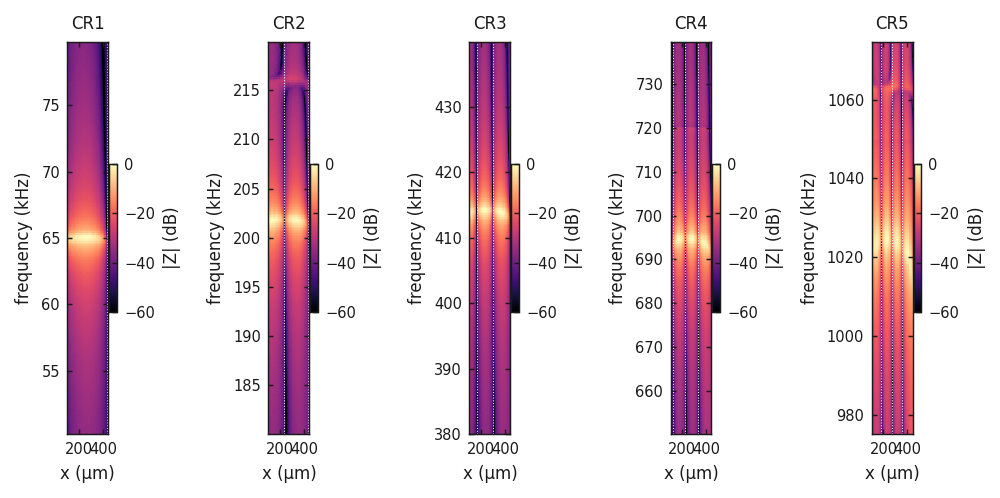

In [4]:
fig, axs = fp.figure("double", aspect=0.5, ncols=5, sharey=False)
for ax, (b, (zb, fb)) in zip(axs, band_data.items()):
    fp.map_db(ax, x, fb, zb)
    for n in truth[b]:
        ax.axvline(n, color="w", lw=0.5, ls=":")
    ax.set_title(b); ax.set_xlabel("x (µm)")
axs[0].set_ylabel("frequency (kHz)")
fig.tight_layout(); fp.save(fig, "02a_ppp_truth_bands")

## Learning curves (cached; about 1 h on first run)

In [5]:
CACHE = F.config.RESULTS_DIR / "_cache_02a.json"
cache = json.loads(CACHE.read_text()) if CACHE.exists() else {}

def held(sel):
    return recon.held_out(len(x), sel)

def err(M, zb, h):
    return float(np.sqrt(np.mean(np.abs(M[h] - zb[h]) ** 2)) / np.sqrt(np.mean(np.abs(zb[h]) ** 2)))

def node_err(M, fb, true_nodes):
    nd, _ = nodes_of(M, fb)
    if not true_nodes:
        return np.nan, len(nd)
    if not nd:
        return np.inf, 0
    return float(np.mean([min(abs(t - m) for m in nd) for t in true_nodes])), len(nd)

for b, (zb, fb) in band_data.items():
    for n in NS:
        key = f"{b}|{n}"
        if key in cache:
            continue
        sel = recon.select_equispaced(x, n); h = held(sel)
        t0 = time.time()
        o = physrec.rec_eb(x, sel, zb[sel], fb, GEOM)
        maps = {"EB": o["Zeb"], "EB+GP": o["Zrec"],
                "GP": recon.rec_gp(x, sel, zb[sel])["Zrec"],
                "low-rank": recon.rec_lowrank(x, sel, zb[sel], rank=min(n, 6))["Zrec"]}
        rec = {"theta": o["theta"], "sec": time.time() - t0, "sel": [int(i) for i in sel]}
        for arm, M in maps.items():
            ne, nn = node_err(M, fb, truth[b])
            rec[arm] = dict(nrmse=err(M, zb, h), node_err_um=ne, n_nodes=nn)
        cache[key] = rec
        CACHE.write_text(json.dumps(cache))
        print(f"{key:7s} {rec['sec']:5.0f}s  " + "  ".join(f"{a} {rec[a]['nrmse']:.3f}" for a in maps))

ARMS = ["EB", "EB+GP", "GP", "low-rank"]
lc = pd.DataFrame([dict(mode=k.split("|")[0], N=int(k.split("|")[1]), arm=a, **v[a])
                   for k, v in cache.items() for a in ARMS])
lc.pivot_table(index=["mode", "N"], columns="arm", values="nrmse").round(4)

CR3|3      41s  EB 0.327  EB+GP 0.322  GP 0.973  low-rank 1.168


CR3|4      22s  EB 0.345  EB+GP 0.332  GP 0.966  low-rank 0.636


CR3|5      26s  EB 0.326  EB+GP 0.278  GP 0.958  low-rank 0.396


CR3|6      41s  EB 0.318  EB+GP 0.231  GP 0.141  low-rank 0.221


CR3|8      69s  EB 0.356  EB+GP 0.218  GP 0.116  low-rank 0.168


CR3|10     62s  EB 0.335  EB+GP 0.195  GP 0.116  low-rank 0.155


CR3|14     66s  EB 0.333  EB+GP 0.160  GP 0.090  low-rank 0.142


CR3|20     74s  EB 0.332  EB+GP 0.135  GP 0.087  low-rank 0.136


CR3|30     89s  EB 0.326  EB+GP 0.115  GP 0.076  low-rank 0.130


arm          EB   EB+GP      GP  low-rank
mode N                                   
CR1  3   0.1504  0.1305  0.5074    0.1348
     4   0.1417  0.1230  0.1169    0.1243
     5   0.1514  0.1106  0.0959    0.0821
     6   0.1505  0.1039  0.0936    0.0957
     8   0.1500  0.0956  0.0851    0.0741
     10  0.1521  0.0854  0.0748    0.0652
     14  0.1506  0.0739  0.0677    0.0617
     20  0.1480  0.0664  0.0613    0.0601
     30  0.1445  0.0630  0.0629    0.0626
CR2  3   0.2348  0.2333  1.0343    0.6235
     4   0.1913  0.1824  0.2294    0.2662
     5   0.1797  0.1447  0.1808    0.1489
     6   0.1796  0.1323  0.1678    0.1301
     8   0.1802  0.1215  0.1027    0.1062
     10  0.1810  0.1073  0.0830    0.0821
     14  0.1818  0.0943  0.0686    0.0747
     20  0.1815  0.0886  0.0719    0.0761
     30  0.1791  0.0814  0.0698    0.0740
CR3  3   0.3274  0.3219  0.9729    1.1684
     4   0.3454  0.3320  0.9663    0.6361
     5   0.3257  0.2777  0.9581    0.3956
     6   0.3181  0.2307  0.1409    0.2215
     8   0.3556  0.2183  0.1164    0.1676
     10  0.3349  0.1949  0.1157    0.1553
     14  0.3334  0.1599  0.0901    0.1419
     20  0.3315  0.1353  0.0874    0.1356
     30  0.3260  0.1154  0.0762    0.1301
CR4  3   0.4551  0.4198  1.3428    1.5793
     4   0.8081  0.8213  1.0195    1.0491
     5   0.4574  0.3763  0.9589    0.7297
     6   0.4496  0.3302  0.9450    0.5272
     8   0.4445  0.2931  0.1834    0.4366
     10  0.4620  0.2748  0.1657    0.4075
     14  0.4487  0.2233  0.1239    0.3858
     20  0.4761  0.2135  0.1087    0.3729
     30  0.4681  0.1829  0.0995    0.3612
CR5  3   1.0407  0.9850  1.0258    0.9428
     4   0.7034  0.6620  0.9961    1.4272
     5   1.0509  0.9903  0.9994    0.9254
     6   0.5784  0.4474  0.9708    0.8280
     8   0.5722  0.4122  0.2701    0.4894
     10  0.5502  0.3566  0.2083    0.4362
     14  0.5550  0.3290  0.1679    0.4053
     20  0.5606  0.2876  0.1456    0.3918
     30  0.5447  0.2404  0.1370    0.3790

[PosixPath('/home/claude/work/paper_analysis/figures/02a_ppp_per_mode_learning_curves.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/02a_ppp_per_mode_learning_curves.pdf')]

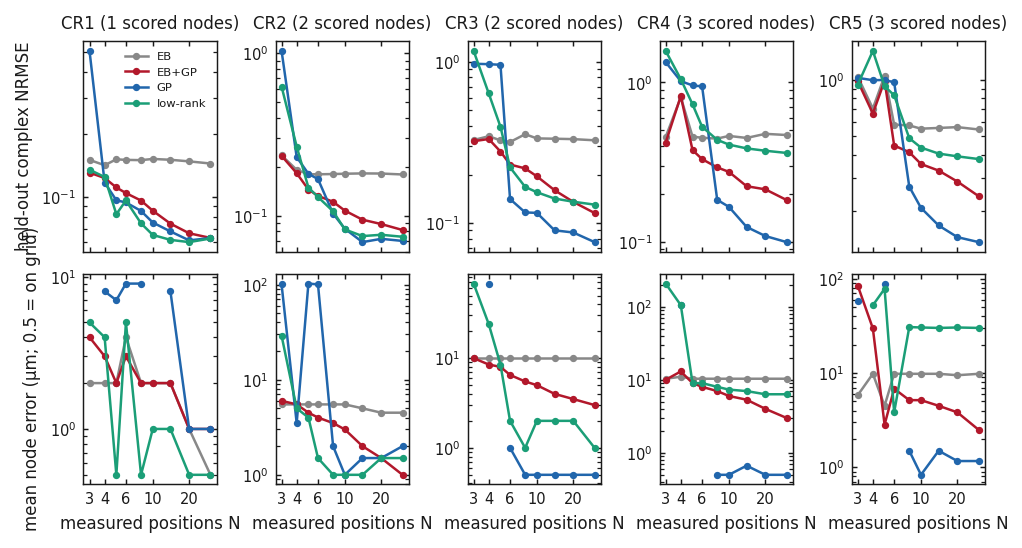

In [6]:
COL = {"EB": fp.C["eb"] if "eb" in fp.C else "0.4", "EB+GP": fp.C["ebgp"], "GP": fp.C["gp"],
       "low-rank": fp.C["lowrank"]}
fig, axs = fp.figure("double", aspect=0.55, ncols=5, nrows=2, sharex=True)
for j, b in enumerate(BANDS):
    d = lc[lc["mode"] == b]
    for a in ARMS:
        da = d[d.arm == a].sort_values("N")
        axs[0, j].plot(da.N, da.nrmse, "o-", ms=2.5, color=COL[a], label=a)
        ne = np.maximum(da.node_err_um.replace(np.inf, np.nan), 0.5)   # 0 -> below the 1 um grid
        axs[1, j].plot(da.N, ne, "o-", ms=2.5, color=COL[a])
    axs[0, j].set_yscale("log"); axs[0, j].set_title(f"{b} ({len(truth[b])} scored nodes)")
    if np.isfinite(d.node_err_um.replace(np.inf, np.nan)).any() and (d.node_err_um > 0).any():
        axs[1, j].set_yscale("log")
    else:
        axs[1, j].text(0.5, 0.5, "no interior node", transform=axs[1, j].transAxes, ha="center", fontsize=6)
    fp.n_axis(axs[1, j])
    axs[1, j].set_xlabel("measured positions N")
axs[0, 0].set_ylabel("held-out complex NRMSE"); axs[1, 0].set_ylabel("mean node error (µm; 0.5 = on grid)")
axs[0, 0].legend(fontsize=5.5)
fig.tight_layout(); fp.save(fig, "02a_ppp_per_mode_learning_curves")

## Crossover: smallest N at which a data-driven arm matches the physics arm

In [7]:
def crossover(d, phys="EB+GP", data_arm="low-rank"):
    # smallest N from which the data-driven arm stays at or below the physics arm for every larger N;
    # robust to budgets where every arm fails (both ~1, order is noise)
    p = d[d.arm == phys].set_index("N").nrmse
    q = d[d.arm == data_arm].set_index("N").nrmse
    ns = [n for n in NS if n in p.index]
    for i, n in enumerate(ns):
        if all(q[m] <= p[m] for m in ns[i:]):
            return n
    return f"never (to N={ns[-1]})"

xo = pd.DataFrame([dict(mode=b, n_nodes=len(truth[b]),
                        lowrank_vs_EBGP=crossover(lc[lc["mode"] == b]),
                        GP_vs_EBGP=crossover(lc[lc["mode"] == b], data_arm="GP"),
                        lowrank_vs_EB=crossover(lc[lc["mode"] == b], phys="EB"))
                   for b in BANDS])
xo

,mode,n_nodes,lowrank_vs_EBGP,GP_vs_EBGP,lowrank_vs_EB
0,CR1,1,5,4,3
1,CR2,2,6,8,5
2,CR3,2,never (to N=30),6,6
3,CR4,3,never (to N=30),8,8
4,CR5,3,never (to N=30),8,8


In [8]:
th = pd.DataFrame([dict(mode=k.split("|")[0], N=int(k.split("|")[1]), **{p: v["theta"].get(p) for p in
                   ("k_ratio", "zeta", "tip_setback_um", "red_chi2")}) for k, v in cache.items()])
th.groupby("mode")[["tip_setback_um", "zeta", "k_ratio"]].agg(["median", "min", "max"]).round(4)

tip_setback_um                      zeta                    k_ratio  \
             median      min      max  median     min     max     median   
mode                                                                       
CR1         16.9250  12.7569  19.4687  0.0048  0.0041  0.0049   348.4875   
CR2          8.7179   7.1055  11.1251  0.0020  0.0019  0.0021  4462.2632   
CR3          7.7773   7.0779   8.6172  0.0013  0.0012  0.0016  2992.8100   
CR4          4.2760   4.0000  13.2505  0.0012  0.0003  0.0036  4070.2242   
CR5          7.0184   4.0032   9.5668  0.0016  0.0013  0.0225  2347.6709   

                              
            min          max  
mode                          
CR1    299.2533     997.3792  
CR2   1494.5900  100000.0000  
CR3   2386.5064    3349.5513  
CR4   1580.2440    4409.9686  
CR5   2190.6302   34386.8183

**Reading guide.** Fill in the text once the numbers are in.
- 2026-09-19 result on the 5 µm sweep: CR1 crossover at N = 4 (physics leads again from N = 14);
  CR2 no crossover up to N = 20.
- Check whether the fitted setback and ζ agree across modes. One lever has one setback: a
  mode-dependent setback means the model is absorbing a missing mechanism.
- Node errors at CR4 and CR5 are the part the 1 µm grid makes possible.

In [9]:
results.save("fig3_ppp_per_mode", dict(truth_nodes=truth, crossover=xo.to_dict("records"),
             geom=GEOM, NS=NS), table=lc)

PosixPath('/home/claude/work/paper_analysis/results/fig3_ppp_per_mode.json')